# Maze-ND substrate: generate data and display figures

TODO


artifact   : artifact:obsfield/categorical-complete/v1
schema     : categorical-field/v1
total rows : 100
inspect id : sha256:094f571e27e75fa98a9757b0ea05070e7c52c4b7964a7b9491870a92249856d9
projection_identity: sha256:b108a7f07ea3267c93e20c6c4542b8302a53614ece83786356a43f99fdf0ffca


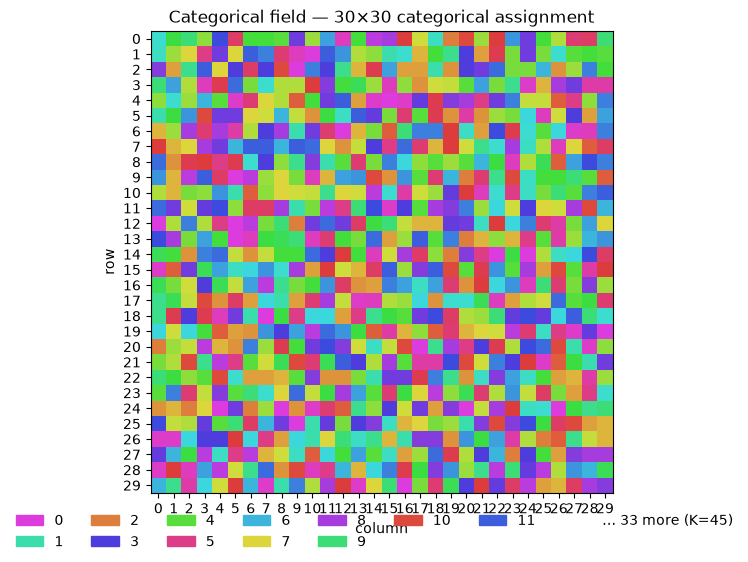

In [4]:
%matplotlib inline
from pathlib import Path

from ehp_sn.artifacts import load_release
from ehp_sn.figures import inspect_figure

# Resolve the committed artifact and choose a deterministic record.
# Record selection is deterministic: sort by canonical record_id, independent
# of build/enumeration order (projection.md "Deterministic selection").
artifact_dir = Path("data/interim/obsfield/categorical-complete/v1")
artifact = load_release(artifact_dir)

records = sorted(artifact.records, key=lambda r: r.record_id)
first = records[0]
print(f"artifact   : {artifact.artifact_ref}")
print(f"schema     : {first.schema_ref}")
print(f"total rows : {len(records)}")
print(f"inspect id : {first.record_id}")

# Record-scope inspection over that one authoritative record (public Python
# API — the same service the CLI `data inspect --figure` path calls).
result = inspect_figure(
    str(artifact_dir),
    first.record_id,
    "figure:categorical-field-inspection/v1",
)
print("projection_identity:", result.projection.identity())

artifact       : artifact:obsfield/categorical-complete/v1
schema         : categorical-field/v1
member records : 100
projection_identity: sha256:5bbfbe326f83c91865c1dd3b3e01e9e90611836980d0501efbdf103729157ed6


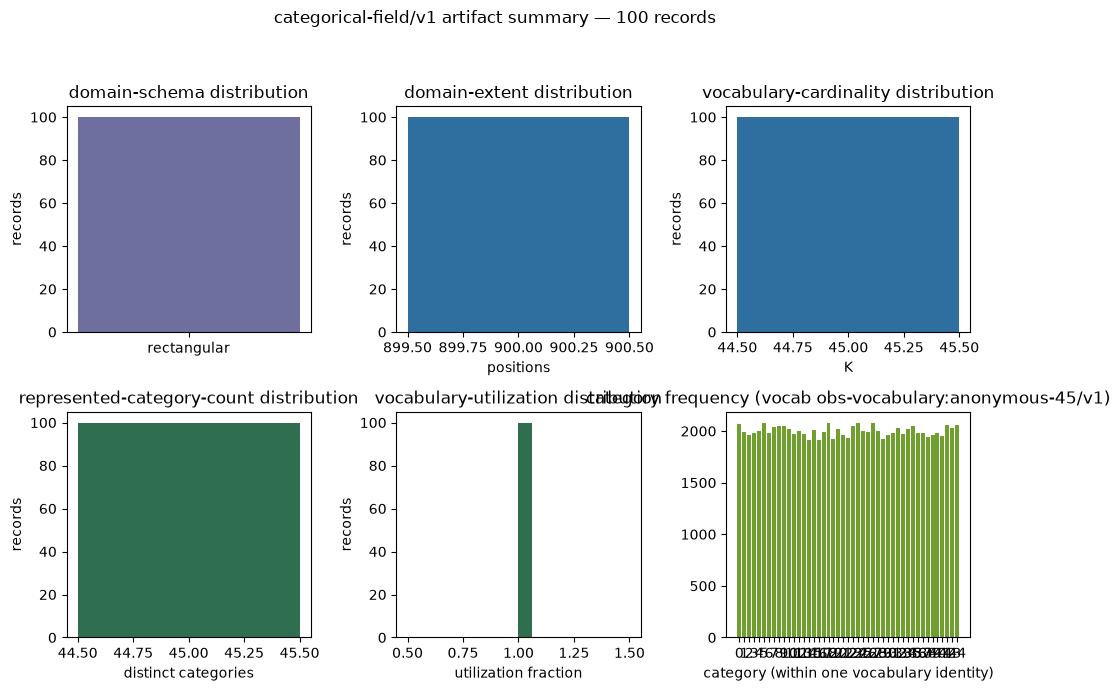

In [5]:
# Artifact-scope summary over the committed record collection. The collection
# schema is derived from the figure's own declared input requirement
# (service.py inspect_artifact_figure); Maze-ND conforms to raster-topology/v1.
from ehp_sn.figures import inspect_artifact_figure

summary = inspect_artifact_figure(
    str(artifact_dir),
    "figure:categorical-field-artifact-summary/v1",
)
proj = summary.projection
print(f"artifact       : {proj.source.artifact_ref}")
print(f"schema         : {proj.source.logical_contract}")
print(f"member records : {len(proj.source.record_ids or ())}")
print("projection_identity:", proj.identity())

artifact       : artifact:obsfield/categorical-complete/v1
schema         : categorical-field/v1
member records : 100
projection_identity: sha256:769a2da17cd40acdfa3c5964666111703006a02cf636d1c4fbf70da8d0f25fab


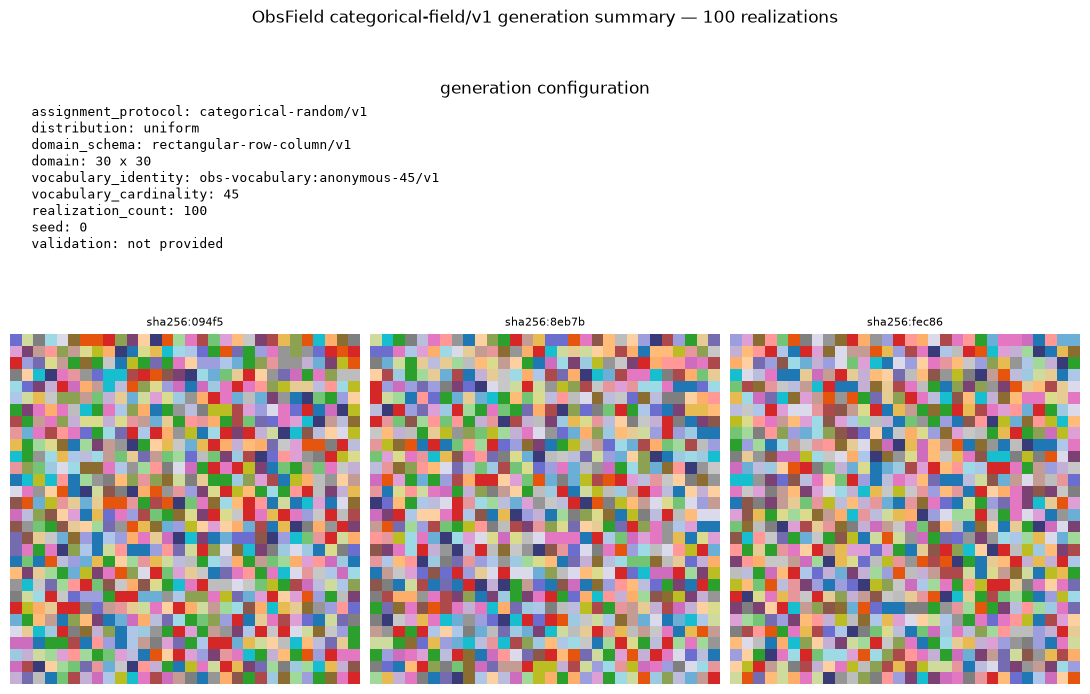

In [6]:
# Artifact-scope summary over the committed record collection. The collection
# schema is derived from the figure's own declared input requirement
# (service.py inspect_artifact_figure); Maze-ND conforms to raster-topology/v1.
from ehp_sn.figures import inspect_artifact_figure

summary = inspect_artifact_figure(
    str(artifact_dir),
    "figure:obsfield-generation-summary/v1",
)
proj = summary.projection
print(f"artifact       : {proj.source.artifact_ref}")
print(f"schema         : {proj.source.logical_contract}")
print(f"member records : {len(proj.source.record_ids or ())}")
print("projection_identity:", proj.identity())